# Diabetes Prediction — Support Vector Machine (SVM)

In this project we build a classification model to predict whether
a patient has diabetes based on medical measurements.

We use the **Pima Indians Diabetes Dataset** which contains real
medical data from 768 female patients aged 21 and above.

- **Target:** `Outcome` — 1 = has diabetes, 0 = no diabetes

We apply Support Vector Machine (SVM) with different kernels and
tune hyperparameters to find the best performing model.

## Sections
- 0: Setup
- 1: Data loading and exploration
- 2: Preprocessing and train/test split
- 3: Kernel comparison — Linear, Polynomial, RBF
- 4: Best model evaluation
- 5: Hyperparameter experiment
- 6: Reflection and key findings

## Sectioin 0 - Setup
Import all libraries needed for this project.

In [1]:
# Section 0 - Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.grid'] = True

print("Setup complete")

Setup complete


## Section 1 - Data Loading and Exploration

In this section we:
- Load the Pima Indians Diabetes dataset directly from the web
- Inspect shape, columns and data types
- Explore the target variable distribution
- Visualise key feature relationships

In [2]:
# Load dataset directly from web
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

col_names = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome'
]

df = pd.read_csv(url, names=col_names)

print("Dataset loaded successfully")
print("Shape: ", df.shape)
df.head()

Dataset loaded successfully
Shape:  (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Pregnancies       768 non-null    int64  
 1   Glucose           768 non-null    int64  
 2   BloodPressure     768 non-null    int64  
 3   SkinThickness     768 non-null    int64  
 4   Insulin           768 non-null    int64  
 5   BMI               768 non-null    float64
 6   DiabetesPedigree  768 non-null    float64
 7   Age               768 non-null    int64  
 8   Outcome           768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
# Check basic statistics
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [5]:
# Replace impossible zero values with column median
# These columns cannot have zero values medically

zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_cols:
  df[col] = df[col].replace(0, df[col].median())


print("Zero values replaced with median!")
print("\nZero counts after replacement")
print((df[zero_cols]==0).sum())

Zero values replaced with median!

Zero counts after replacement
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


Target Distribution: 
Outcome
0    500
1    268
Name: count, dtype: int64

Target Percentage: 
Outcome
0    0.65
1    0.35
Name: proportion, dtype: float64


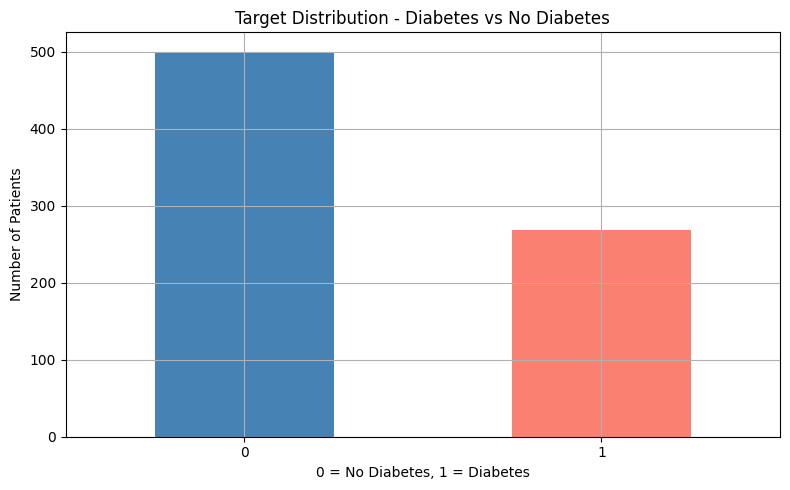

In [6]:
# Check target distribution
print("Target Distribution: ")
print(df['Outcome'].value_counts())
print()
print("Target Percentage: ")
print(df['Outcome'].value_counts(normalize=True).round(2))

#Visualise
df['Outcome'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.title('Target Distribution - Diabetes vs No Diabetes')
plt.xlabel('0 = No Diabetes, 1 = Diabetes')
plt.ylabel('Number of Patients')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

## Sectionn 2 - Preprocessing and Train/Test Split

In this section we:
- Define X(features) and y(target)
- Split into train and test sets
- Scale features using StandardScaler

In [7]:
# Define features and target
X = df.drop(columns=['Outcome'])
y = df['Outcome']

print("X shape: ",X.shape)
print("y shape: ",y.shape)
print("\nFeatures: ",X.columns.tolist())

X shape:  (768, 8)
y shape:  (768,)

Features:  ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age']


In [8]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size: ", X_train.shape)
print("Test size: ", X_test.shape)
print("\nTrain target distribution: ")
print(y_train.value_counts(normalize=True).round(2))

Train size:  (614, 8)
Test size:  (154, 8)

Train target distribution: 
Outcome
0    0.65
1    0.35
Name: proportion, dtype: float64


In [9]:
# Scale features using StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")
print("X_train mean (should be approximately 0): ", X_train_scaled.mean().round(4))
print("X_train std  (should be approximately 1): ", X_train_scaled.std().round(4))

Scaling complete
X_train mean (should be approximately 0):  0.0
X_train std  (should be approximately 1):  1.0


## Section 3 - Kernel Comparison

We train SVM with three different kernels and compare:
- Linear Kernel
- Polynomial Kernel(degree = 3)
- RBF Kernel

This shows how kernel choice affects performance on real medical data.

In [10]:
# Train three SVN models with different kernels
kernels = [
    ('linear', SVC(kernel='linear', C=1.0, random_state=42)),
    ('poly', SVC(kernel='poly', degree=3, C=1.0, gamma='scale', random_state=42)),
    ('rbf', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
]

results = []

for name, model in kernels:
  model.fit(X_train_scaled, y_train)
  y_pred = model.predict(X_test_scaled)
  acc = accuracy_score(y_test, y_pred)
  results.append({'kernel': name, 'accuracy': round(acc, 4)})
  print(f"{name:8s} kernel accuracy: {acc:.4f}")

df_kernels = pd.DataFrame(results)

linear   kernel accuracy: 0.7078
poly     kernel accuracy: 0.7143
rbf      kernel accuracy: 0.7338


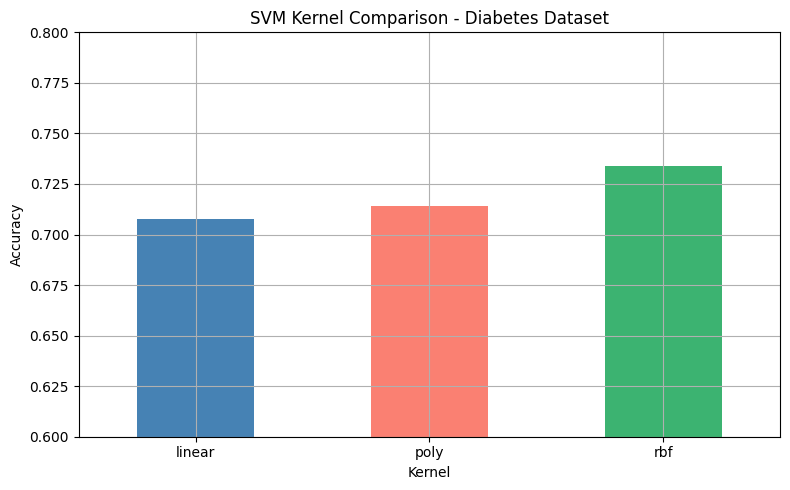

In [11]:
# Plot kernel comparison
df_kernels.plot(kind='bar', x='kernel', y='accuracy',
                color=['steelblue', 'salmon', 'mediumseagreen'],
                legend = False
                )

plt.title('SVM Kernel Comparison - Diabetes Dataset')
plt.xlabel('Kernel')
plt.ylabel('Accuracy')
plt.xticks(rotation=0)
plt.ylim(0.6, 0.8)
plt.tight_layout()
plt.show()

## Section 4 - Best Model Evaluation

RBF Kernel performed best in Section 3
We now evaluate it fully using:
- Confusion matrix
- Classification report
- Visualised confusion matrix heatmap

In [12]:
# Train best model - RBF kernel
svc_best = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svc_best.fit(X_train_scaled, y_train)

# Predict
y_pred = svc_best.predict(X_test_scaled)

# Accuracy
print("Best model accuracy: ", round(accuracy_score(y_test, y_pred),4))

Best model accuracy:  0.7338


In [14]:
# Full classification report
print(classification_report(y_test, y_pred,
      target_names=['No Diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.77      0.84      0.80       100
    Diabetes       0.64      0.54      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.69       154
weighted avg       0.73      0.73      0.73       154



Confusion Matrix
[[84 16]
 [25 29]]


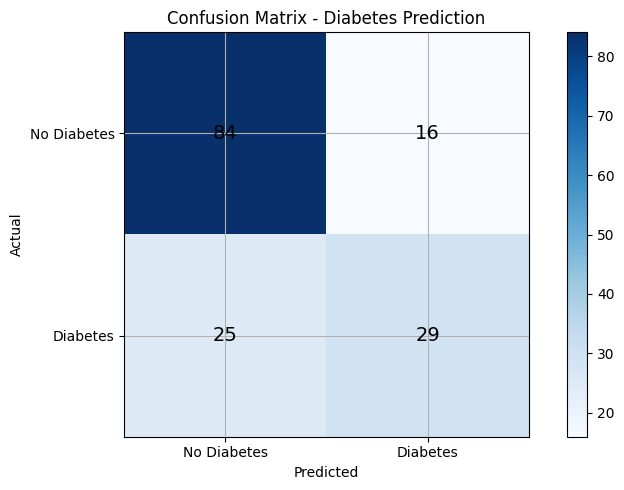

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix")
print(cm)

# Visualise
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - Diabetes Prediction')
plt.colorbar()
plt.xticks([0,1], ['No Diabetes', 'Diabetes'])
plt.yticks([0,1], ['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')

for i in range(2):
  for j in range(2):
    plt.text(j, i, cm[i,j], ha='center', va='center',
             color='black', fontsize=14)


plt.tight_layout()
plt.show()

## Section 5 - Hyperparameter Experiment

We test different combinations off C and gamma to find the best performing RBF SVM on the diabetes dataset.

In [17]:
# Manual grid search over  C and gamma
C_values = [0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 'scale']

results = []

for C in C_values:
  for gamma in gamma_values:
    model = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred_gs = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_gs)
    results.append({'C': C, 'gamma': gamma, 'accuracy': round(acc,4)})


df_results = pd.DataFrame(results)
df_results.sort_values('accuracy', ascending = False).head(10)

,C,gamma,accuracy
3,0.1,scale,0.7338
2,0.1,0.1,0.7338
6,1.0,0.1,0.7338
7,1.0,scale,0.7338
13,100.0,0.01,0.7338
11,10.0,scale,0.7273
10,10.0,0.1,0.7273
5,1.0,0.01,0.7143
8,10.0,0.001,0.7143
9,10.0,0.01,0.7143


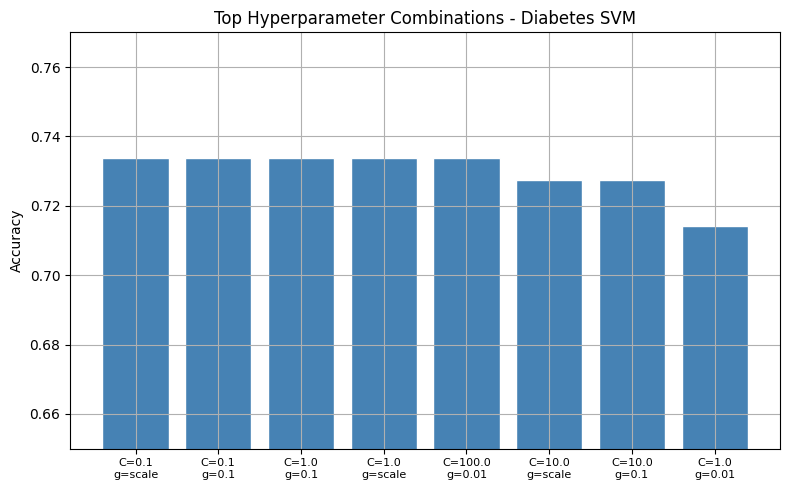

In [18]:
# Plot top resutls
top_results = df_results.sort_values('accuracy', ascending=False).head(8)
labels = [f"C={row['C']}\ng={row['gamma']}" for _, row in top_results.iterrows()]

plt.bar(range(len(top_results)), top_results['accuracy'],
        color='steelblue', edgecolor='white')

plt.xticks(range(len(top_results)), labels, fontsize=8)
plt.ylim(0.65, 0.77)
plt.ylabel('Accuracy')
plt.title('Top Hyperparameter Combinations - Diabetes SVM')
plt.tight_layout()
plt.show()

## Section 6 - Reflection and Key Findings
**1. Which Kernel performed Best?**
RBF kernel performed best with 73.38% accuracy. It captures the non-linear relationships between medical features and diabetes outcome better than linear or polynomial kernels.

**2. Why is accuracy not enough here?**
The dataset is imbalanced - 65% no diabetes vs 35% diabetes. The model only catches 54% of actual diabetic patients (recall=0.54). In healthcare, missing a diabetic patient is far more dangerous than a false alarm. Recall is the most important metric here.

**3. What did hyperparameter tuing show?**
Multiple C and gamma combinations tied at 73.38% - suggesting the dataset has a performance ceiling for basic SVM. Lower C values(0.1, 1.0) with gamma='scale' are the most reliable choice.

**4. What would improve the model?**
- Class weights to handle imbalance: SVC(class_weight='balanced')
- More advanced techniques like GridSearchCV with cross-validation
- Feature engineering - combining features like glucose x BMI
- Ensemble methods like Random Forest in future modules.

**5. Real world implication**
Diabetes prediction from basic medical measurements is genuinely hard. The 25 missed diabetic patients highlight why ML models in healtcare must always be used alongside clinical judgement - never as a replacement.